In [51]:
import torch 
import torchvision
import numpy as np
import matplotlib.pyplot as plt


In [52]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  
])

dataset_train = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True,
)
dataset_test = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True,
)

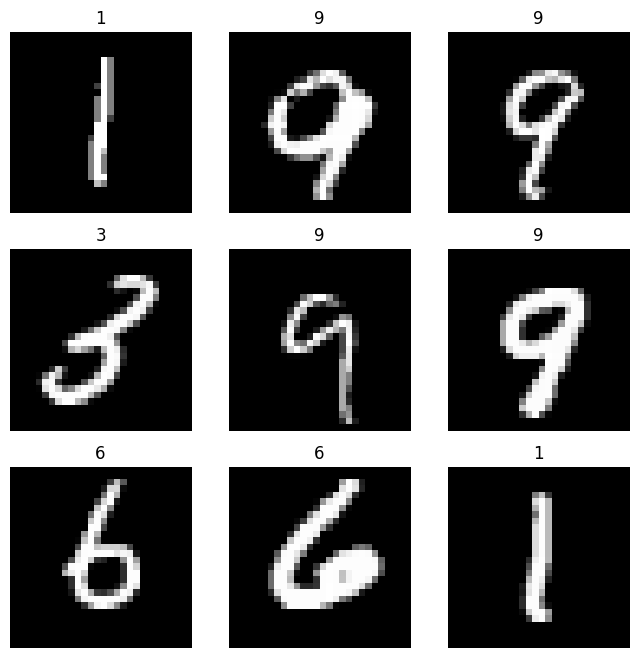

In [53]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(dataset_train), size=(1,)).item()
    img, label = dataset_train[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis('off')
    plt.imshow(img.squeeze(), cmap='gray')  # (1,28,28) → (28,28)
plt.show()

In [54]:
from torch.utils.data import DataLoader

dataset_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
dataset_test  = DataLoader(dataset_test,  batch_size=64, shuffle=False)

In [55]:
train_features, train_labels = next(iter(dataset_train))
train_features.size()

torch.Size([64, 1, 28, 28])

In [56]:
import torch.nn as nn

In [57]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

In [58]:
mlp = MLP()
print(mlp)

n_params = sum(p.numel() for p in mlp.parameters()if p.requires_grad)
print(f"Nombre de paramètres : {n_params}")

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)
Nombre de paramètres : 109386


In [59]:
x_dummy = torch.randn(1, 784)
output = mlp(x_dummy)
print(f"[2.4] Forward pass entrée : {x_dummy.shape} → sortie : {output.shape}")
print(f"Sortie  : {output}")

[2.4] Forward pass entrée : torch.Size([1, 784]) → sortie : torch.Size([1, 10])
Sortie  : tensor([[-0.0250, -0.0667, -0.0250, -0.0152, -0.0082, -0.0694,  0.1658, -0.0175,
          0.0174, -0.0976]], grad_fn=<AddmmBackward0>)


In [60]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(mlp.parameters(), lr=0.01)

In [61]:
def train_loop(dataloader,model,criterion,optimizer) : 
    size = len(dataloader.dataset)
    model.train()
    for batch, (x,y) in enumerate(dataloader) :
        pred = model(x)
        loss = criterion(pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        if batch % 100 == 0 :
            loss, current = loss.item(), batch * len(x)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader,model,criterion) :
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0,0


    with torch.no_grad() :
        for x,y in dataloader :
            pred = model(x)
            test_loss += criterion(pred,y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    test_loss /= num_batches
    correct /= size
    print(f"Test Error : \n Accuracy : {(100*correct):>0.1f}%, Avg loss : {test_loss:>8f} \n")
    

In [62]:
epochs = 5
for t in range(epochs) :
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(dataset_train,mlp,criterion,optimizer)
    test_loop(dataset_test,mlp,criterion)

Epoch 1
-------------------------------
loss: 2.288057  [    0/60000]
loss: 2.102094  [ 6400/60000]
loss: 1.652284  [12800/60000]
loss: 1.022754  [19200/60000]
loss: 0.673923  [25600/60000]
loss: 0.722598  [32000/60000]
loss: 0.649753  [38400/60000]
loss: 0.434465  [44800/60000]
loss: 0.458573  [51200/60000]
loss: 0.464454  [57600/60000]
Test Error : 
 Accuracy : 88.7%, Avg loss : 0.412502 

Epoch 2
-------------------------------
loss: 0.447935  [    0/60000]
loss: 0.388255  [ 6400/60000]
loss: 0.421407  [12800/60000]
loss: 0.443369  [19200/60000]
loss: 0.332463  [25600/60000]
loss: 0.394575  [32000/60000]
loss: 0.453861  [38400/60000]
loss: 0.407897  [44800/60000]
loss: 0.389096  [51200/60000]
loss: 0.214775  [57600/60000]
Test Error : 
 Accuracy : 88.9%, Avg loss : 0.361570 

Epoch 3
-------------------------------
loss: 0.356583  [    0/60000]
loss: 0.302759  [ 6400/60000]
loss: 0.234952  [12800/60000]
loss: 0.250754  [19200/60000]
loss: 0.334942  [25600/60000]
loss: 0.324878  [320